# Portfolio Optimization Model
## Mean-Variance Optimization & Efficient Frontier
### Cynthia Wanjiru | WashU MSFQ 2026'

!pip install pyportfolioopt

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from pypfopt import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns
from pypfopt import plotting

## Step 1: Download Historical Price Data
Download 5 years of daily closing prices for 10 stocks across 
Tech, Finance, Healthcare, Consumer goods, and Retail sectors.

In [3]:
tickers = ['MSFT', 'GOOGL', 'JPM', 'GS', 'JNJ', 
           'PFE', 'AMZN', 'BRK-B', 'TGT', 'WMT']

data = yf.download(tickers, start='2019-01-01', end='2024-12-31')['Close']

print(f"Downloaded {len(data)} trading days of data")
print(f"Date range: {data.index[0].date()} to {data.index[-1].date()}")
print(f"\nFirst 5 rows:")
data.head()

[*********************100%***********************]  10 of 10 completed

Downloaded 1509 trading days of data
Date range: 2019-01-02 to 2024-12-30

First 5 rows:


Ticker,AMZN,BRK-B,GOOGL,GS,JNJ,JPM,MSFT,PFE,TGT,WMT
Date,,,,,,,,,,
2019-01-02,76.956497,202.800003,52.338543,145.391663,104.387894,81.250191,94.397148,29.294361,54.379154,28.024445
2019-01-03,75.014000,191.660004,50.888996,143.261871,102.729126,80.095490,90.924492,28.474791,53.634338,27.880325
2019-01-04,78.769501,195.199997,53.499271,147.944016,104.453278,83.048264,95.153290,29.125027,54.370972,28.054468
2019-01-07,81.475502,196.910004,53.392582,148.763840,103.783226,83.105980,95.274651,29.280807,57.030994,28.384735
2019-01-08,82.829002,196.309998,53.861538,148.214447,106.193741,82.949287,95.965454,29.416273,56.973705,28.582890


## Step 2: Calculate Expected Returns & Covariance Matrix
Historical returns are used the expected returns estimate and 
the sample covariance matrix captures how stocks move together.

In [4]:
# Calculate expected returns and covariance matrix
mu = expected_returns.mean_historical_return(data)
cov_matrix = risk_models.sample_cov(data)

print("Expected Annual Returns:")
print(mu.round(4) * 100)
print(f"\nCovariance Matrix Shape: {cov_matrix.shape}")

Expected Annual Returns:
Ticker
AMZN     19.31
BRK-B    14.34
GOOGL    24.10
GS       25.24
JNJ       4.82
JPM      19.28
MSFT     28.37
PFE      -3.12
TGT      15.39
WMT      21.46
dtype: float64

Covariance Matrix Shape: (10, 10)


## Step 3: Optimize Portfolio — Maximum Sharpe Ratio
Calculate the portfolio weights that maximize the portfolio Sharpe Ratio


In [5]:
ef = EfficientFrontier(mu, cov_matrix)
weights = ef.max_sharpe(risk_free_rate=0.05)
cleaned_weights = ef.clean_weights()

print("Optimal Portfolio Weights (Maximum Sharpe Ratio):")
for ticker, weight in cleaned_weights.items():
    print(f"{ticker}: {weight*100:.2f}%")

print("\nPortfolio Performance:")
expected_return, volatility, sharpe_ratio = ef.portfolio_performance(risk_free_rate=0.05)
print(f"Expected Annual Return: {expected_return*100:.2f}%")
print(f"Annual Volatility:      {volatility*100:.2f}%")
print(f"Sharpe Ratio:           {sharpe_ratio:.2f}")

Optimal Portfolio Weights (Maximum Sharpe Ratio):
AMZN: 0.00%
BRK-B: 0.00%
GOOGL: 0.00%
GS: 17.98%
JNJ: 0.00%
JPM: 0.00%
MSFT: 33.34%
PFE: 0.00%
TGT: 0.00%
WMT: 48.69%

Portfolio Performance:
Expected Annual Return: 24.45%
Annual Volatility:      19.83%
Sharpe Ratio:           0.98


## Step 4: Plot the Efficient Frontier
Simulate 10,000 random portfolios to visualize the risk-return 
tradeoff.

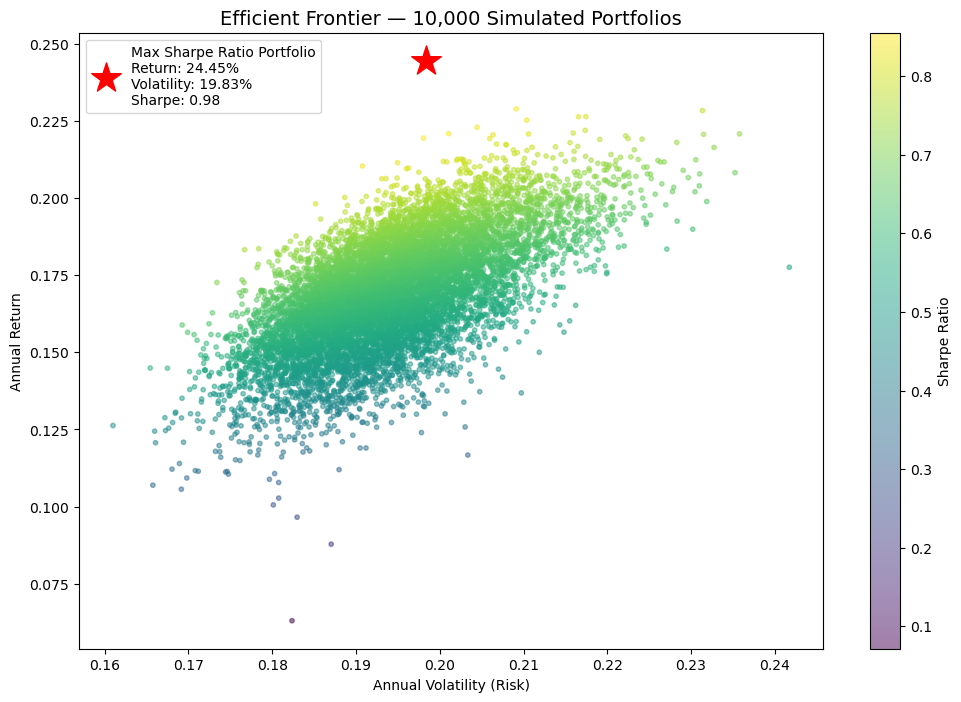

In [6]:
# Simulate 10,000 random portfolios
num_portfolios = 10000
results = np.zeros((3, num_portfolios))

for i in range(num_portfolios):
    # Generate random weights
    w = np.random.random(len(tickers))
    w = w / np.sum(w)
    
    # Calculate portfolio return and volatility
    portfolio_return = np.dot(w, mu)
    portfolio_volatility = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))
    
    # Store results
    results[0, i] = portfolio_volatility
    results[1, i] = portfolio_return
    results[2, i] = (portfolio_return - 0.05) / portfolio_volatility

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(results[0], results[1], c=results[2], 
            cmap='viridis', alpha=0.5, s=10)
plt.colorbar(label='Sharpe Ratio')

# Plot the optimal portfolio
ef2 = EfficientFrontier(mu, cov_matrix)
ef2.max_sharpe(risk_free_rate=0.05)
ret, vol, sharpe = ef2.portfolio_performance(risk_free_rate=0.05)
plt.scatter(vol, ret, color='red', marker='*', s=500, 
            label=f'Max Sharpe Ratio Portfolio\nReturn: {ret*100:.2f}%\nVolatility: {vol*100:.2f}%\nSharpe: {sharpe:.2f}')

plt.title('Efficient Frontier — 10,000 Simulated Portfolios', fontsize=14)
plt.xlabel('Annual Volatility (Risk)')
plt.ylabel('Annual Return')
plt.legend()
plt.show()

## Summary

In [7]:
print("=" * 50)
print("PORTFOLIO OPTIMIZATION — SUMMARY")
print("=" * 50)
print(f"Universe: 10 stocks across 5 sectors")
print(f"Period: 2019 - 2024 (1,509 trading days)")
print(f"Simulated Portfolios: 10,000")
print("-" * 50)
print("Optimal Weights (Maximum Sharpe Ratio):")
for ticker, weight in cleaned_weights.items():
    if weight > 0:
        print(f"  {ticker:8} {weight*100:.2f}%")
print("-" * 50)
print(f"Expected Annual Return: {ret*100:.2f}%")
print(f"Annual Volatility:      {vol*100:.2f}%")
print(f"Sharpe Ratio:           {sharpe:.2f}")
print("=" * 50)

PORTFOLIO OPTIMIZATION — SUMMARY
Universe: 10 stocks across 5 sectors
Period: 2019 - 2024 (1,509 trading days)
Simulated Portfolios: 10,000
--------------------------------------------------
Optimal Weights (Maximum Sharpe Ratio):
  GS       17.98%
  MSFT     33.34%
  WMT      48.69%
--------------------------------------------------
Expected Annual Return: 24.45%
Annual Volatility:      19.83%
Sharpe Ratio:           0.98
